# 02 - Elo Ratings

Fit the Elo model by replaying matches chronologically, then inspect the resulting ratings and a sample prediction.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

from wcpredictor.models import EloModel

In [2]:
tr = build_training_matches(load_matches(config), config)
teams = load_teams(config)
elo = EloModel(config).fit(tr)
table = elo.ratings_table(teams)
table.head(20)

,team,rating,confederation,pot
0,Croatia,1661.394358,UEFA,2
1,Spain,1657.096803,UEFA,1
2,France,1637.014147,UEFA,1
3,Brazil,1616.704865,CONMEBOL,1
4,Argentina,1616.324047,CONMEBOL,1
5,Netherlands,1610.333968,UEFA,1
6,Germany,1605.255771,UEFA,1
7,Uruguay,1603.363203,CONMEBOL,1
8,Colombia,1592.290843,CONMEBOL,2
9,Morocco,1569.239472,CAF,1


## Top 15 teams by Elo

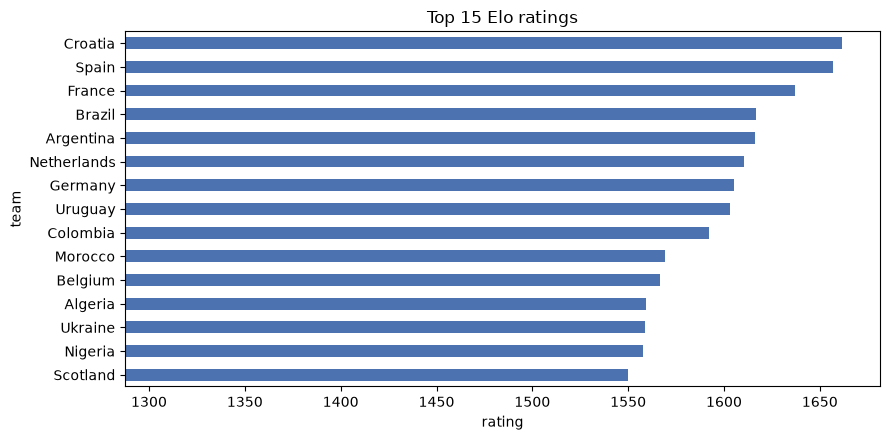

In [3]:
top = table.head(15).iloc[::-1]
ax = top.plot.barh(x='team', y='rating', legend=False, color='#4C72B0')
ax.set_title('Top 15 Elo ratings'); ax.set_xlabel('rating')
ax.set_xlim(table['rating'].min() - 20, table['rating'].max() + 20)
plt.tight_layout(); plt.show()

## Average rating by confederation

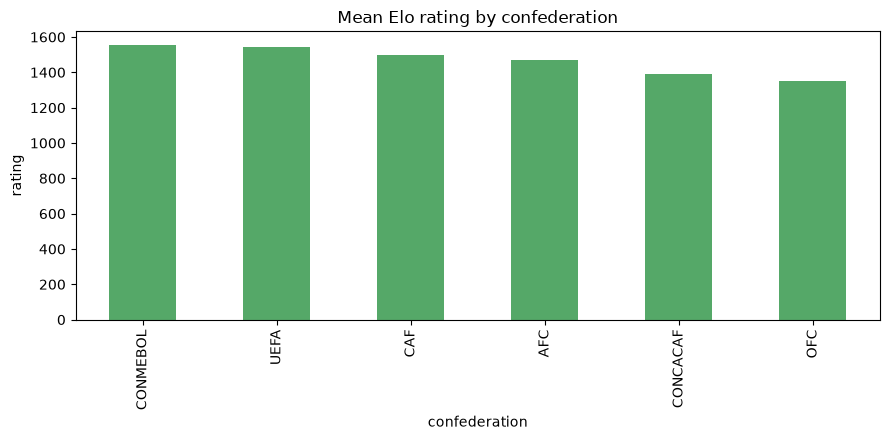

confederation
CONMEBOL    1554.361276
UEFA        1540.772347
CAF         1497.160998
AFC         1471.060887
CONCACAF    1390.997503
OFC         1351.008994
Name: rating, dtype: float64

In [4]:
by_conf = table.groupby('confederation')['rating'].mean().sort_values(ascending=False)
ax = by_conf.plot.bar(color='#55A868')
ax.set_title('Mean Elo rating by confederation')
ax.set_ylabel('rating'); plt.tight_layout(); plt.show()
by_conf

## Sample prediction

In [5]:
pred = elo.predict_match('Brazil', 'Germany', neutral=True)
print(f'Brazil win: {pred.p_home_win:.1%}')
print(f'Draw:       {pred.p_draw:.1%}')
print(f'Germany win:{pred.p_away_win:.1%}')

Brazil win: 38.6%
Draw:       26.1%
Germany win:35.3%
